In [45]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display
from qutip import spin_Jx, spin_Jy, spin_Jz, spin_coherent
from scipy.linalg import expm

In [46]:
J = 4.5
J_x = spin_Jx(J).full()
J_y = spin_Jy(J).full()
J_z = spin_Jz(J).full()
def expect(obs, state):
    """Compute the expectation value of an observable."""
    return np.real(np.trace(obs @ state))

def bloch_coordinates(state):
    """Compute the Bloch coordinates of a state."""
    x = expect(J_x, state)
    y = expect(J_y, state)
    z = expect(J_z, state)
    return np.array([x, y, z])/J

def platonic_solid_vertices(solid):
    if solid == 'tetrahedron':
        return np.array([[1, 1, 1], [-1, -1, 1], [-1, 1, -1], [1, -1, -1]]) / np.sqrt(3)
    elif solid == 'cube':
        return np.array([[1, 1, 1], [-1, 1, 1], [-1, -1, 1], [1, -1, 1],
                         [1, -1, -1], [-1, -1, -1], [-1, 1, -1], [1, 1, -1]]) / np.sqrt(3)
    elif solid == 'octahedron':
        return np.array([[0, 0, 1], [1, 0, 0], [0, 1, 0], [-1, 0, 0],
                         [0, -1, 0], [0, 0, -1]])
    elif solid == 'icosahedron':
        phi = (1 + np.sqrt(5)) / 2
        return np.array([[0, phi, 1], [-phi, 1, 0], [-1, 0, phi], [1, 0, phi],
                         [phi, 1, 0], [0, phi, -1], [-1, 0, -phi], [1, 0, -phi],
                         [phi, -1, 0], [0, -phi, 1], [-phi, -1, 0], [0, -phi, -1]]) / np.sqrt(1 + phi**2)
    elif solid == 'dodecahedron':

        phi = (1 + np.sqrt(5)) / 2
        a = 1/phi

        return np.array([
            [ 1,  1,  1],
            [ 0,  a,  phi],
            [-1,  1,  1],
            [-a,  phi, 0],
            [ a,  phi, 0],
            [ 1,  1, -1],
            [ phi, 0, -a],
            [ phi, 0,  a],
            [ 1, -1,  1],
            [ 0, -a,  phi],
            [-1, -1,  1],
            [-phi, 0,  a],
            [-phi, 0, -a],
            [-1,  1, -1],
            [ 0,  a, -phi],
            [ 0, -a, -phi],
            [ 1, -1, -1],
            [ a, -phi, 0],
            [-a, -phi, 0],
            [-1, -1, -1],
        ])/np.sqrt(3)


In [ ]:
platonic_solids = np.array(['tetrahedron', 'cube', 'octahedron', 'icosahedron', 'dodecahedron'])
solid = platonic_solid_vertices(platonic_solids[4])
solid_angle = np.arccos(np.vdot(solid[0], solid[1]))
cross_solid = [np.cross(solid[i], solid[(i+1)]) / np.linalg.norm(np.cross(solid[i], solid[(i+1)])) for i in range(len(solid)-1)]
in_state = spin_coherent(J, np.arccos(solid[0][2]), math.atan2(solid[0][1], solid[0][0]), type = 'dm').full()
state = in_state
delta_t = 0.001
t_steps = 7000
t_global = 0
w = np.random.normal(0, 0.01, 3)
#w = [0.12, 0.04, 0.04]
bloch_array = [None] * (t_steps + 1)
bloch_array[0] = bloch_coordinates(state)
U_w = expm(-1j * (w[0] * J_x + w[1] * J_y + w[2] * J_z) * delta_t)
U_w_dagger = expm(1j * (w[0] * J_x + w[1] * J_y + w[2] * J_z) * delta_t)

for cross_idx, cross in enumerate(cross_solid):
    if cross_idx == len(cross_solid) - 1:
        t_per_cross = t_steps - t_global
    else:
        t_per_cross = t_steps // len(cross_solid)

    omega_cross = solid_angle / (t_per_cross * delta_t)
    U = expm(-1j * (cross[0] * J_x + cross[1] * J_y + cross[2] * J_z) * delta_t * omega_cross)
    U_dagger = expm(1j * (cross[0] * J_x + cross[1] * J_y + cross[2] * J_z) * delta_t * omega_cross)
    for i in range(t_per_cross):
        t_global += 1
        state = U_w @ U @ state @ U_dagger @ U_w_dagger
        bloch_array[t_global] = bloch_coordinates(state)

bloch_array = np.array(bloch_array)

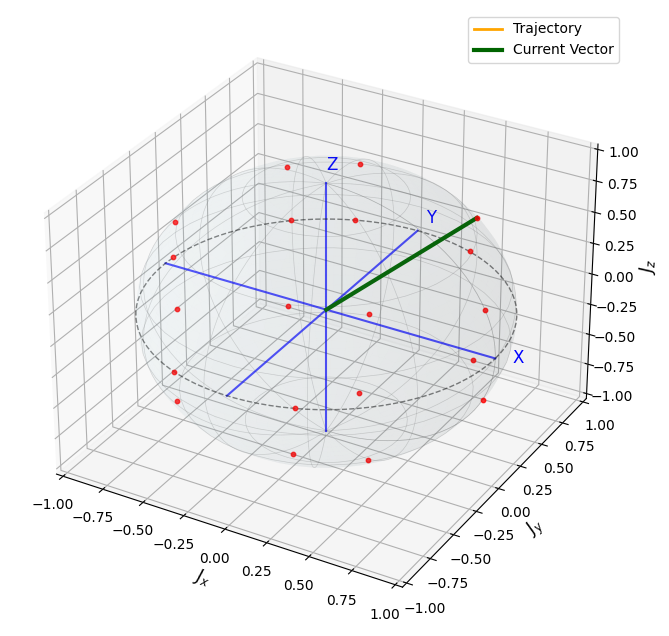

In [100]:
t = 50
Jx = bloch_array[:,0][0::t]
Jy = bloch_array[:,1][0::t]
Jz = bloch_array[:,2][0::t]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")

# Set axis limits and labels
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel(r"$J_x$", fontsize=12)
ax.set_ylabel(r"$J_y$", fontsize=12)
ax.set_zlabel(r"$J_z$", fontsize=12)

# Add a grid for better depth perception
ax.grid(True, alpha=0.3)

# Draw Bloch sphere with wireframe
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 50)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))

# Draw sphere with low alpha and wireframe
ax.plot_surface(xs, ys, zs, alpha=0.05, color='lightblue', linewidth=0, antialiased=True)

# Add longitude lines (vertical great circles)
for phi in np.linspace(0, 2*np.pi, 12):
    x = np.cos(phi) * np.sin(np.linspace(0, np.pi, 50))
    y = np.sin(phi) * np.sin(np.linspace(0, np.pi, 50))
    z = np.cos(np.linspace(0, np.pi, 50))
    ax.plot(x, y, z, color='gray', alpha=0.3, linewidth=0.5)

# Add latitude lines (horizontal circles)
for theta in np.linspace(0, np.pi, 8)[1:-1]:  # Skip poles
    r = np.sin(theta)
    z_val = np.cos(theta)
    phi = np.linspace(0, 2*np.pi, 50)
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    z = np.ones_like(phi) * z_val
    ax.plot(x, y, z, color='gray', alpha=0.3, linewidth=0.5)

# Draw coordinate axes with labels
# X-axis (red)
ax.plot([-1, 1], [0, 0], [0, 0], color='blue', alpha=0.7, linewidth=1.5)
ax.text(1.1, 0, 0, 'X', color='blue', fontsize=12)

# Y-axis (green)
ax.plot([0, 0], [-1, 1], [0, 0], color='blue', alpha=0.7, linewidth=1.5)
ax.text(0, 1.1, 0, 'Y', color='blue', fontsize=12)

# Z-axis (blue)
ax.plot([0, 0], [0, 0], [-1, 1], color='blue', alpha=0.7, linewidth=1.5)
ax.text(0, 0, 1.1, 'Z', color='blue', fontsize=12)

#Add platonic solid vertices
for vertex in solid:
    ax.scatter(vertex[0], vertex[1], vertex[2], color='red', s=10, alpha=0.8)

# Add equator line (special highlight)
phi_eq = np.linspace(0, 2*np.pi, 100)
x_eq = np.cos(phi_eq)
y_eq = np.sin(phi_eq)
z_eq = np.zeros_like(phi_eq)
ax.plot(x_eq, y_eq, z_eq, color='black', alpha=0.5, linewidth=1, linestyle='--')


# Trajectory + vector
traj, = ax.plot([], [], [], lw=2, color='orange', label='Trajectory')
vec, = ax.plot([], [], [], lw=3, color='darkgreen', label='Current Vector')

# Add legend
ax.legend(loc='upper right')

def update(frame):
    traj.set_data(Jx[:frame], Jy[:frame])
    traj.set_3d_properties(Jz[:frame])
    vec.set_data([0, Jx[frame]], [0, Jy[frame]])
    vec.set_3d_properties([0, Jz[frame]])
    return traj, vec

ani = animation.FuncAnimation(fig, update, frames=len(Jx), interval=40)
ani.save(f'bloch_vector.mp4', writer='ffmpeg', fps=30, dpi=200)
#display(HTML(ani.to_jshtml()))